# Capstone Project: AwasLink

## Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana distribusi jumlah dan persentase pesan phishing dan pesan normal pada dataset yang digunakan, serta bagaimana ketidakseimbangan data tersebut memengaruhi strategi pelatihan model klasifikasi?
- **Pertanyaan 2:** Kata-kata apa yang paling dominan pada pesan phishing dibandingkan pesan normal dalam dataset yang digunakan, dan bagaimana pola frekuensi kemunculan kata tersebut dapat dimanfaatkan sebagai fitur dalam proses deteksi phishing?
- **Pertanyaan 3:** Bagaimana karakteristik pesan phishing dan pesan normal berdasarkan fitur numerik seperti panjang pesan, jumlah angka, dan rasio huruf kapital, serta bagaimana pola fitur  tersebut dapat dimanfaatkan dalam proses deteksi phishing?
- **Pertanyaan 4:**
Bagaimana perbedaan kemunculan indikator phishing seperti kata mendesak, kata sensitif, URL, nomor telepon, nama brand, dan simbol tertentu pada pesan phishing dibandingkan pesan normal, serta bagaimana indikator tersebut dapat membantu proses deteksi phishing?


## Import Packages/Library

In [3]:
import pandas as pd
import numpy as np
import re
import ipaddress
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from urllib.parse import urlparse
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import scipy.sparse as sp

## Data Wrangling

### 1.  Gathering Data


Memuat dataset untuk analisis pola phishing dan spam

In [4]:
drive.mount('/content/drive')
folder_dataset = '/content/drive/MyDrive/Capstone Project_new/Dataset/'

Mounted at /content/drive


In [5]:
df1 = pd.read_csv(folder_dataset + 'dataset_sms_spam_v2.csv')
df1.head()

,Teks,label
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,promo
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,promo
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",promo
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",promo
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,promo


In [6]:
df2 = pd.read_csv(folder_dataset + 'sms_spam_indo.csv')
df2.head()

,Kategori,Pesan
0,spam,Plg Yth: Simcard anda mendptkan bonus poin plu...
1,ham,Iya ih ko sedih sih gtau kapan lg ke bandung :(
2,ham,Kalau mau bikin model/controller mending per a...
3,ham,Selamat nama1. Semoga selalu menempuh hidup ya...
4,spam,Tingkatkan nilai isi ulang Anda selanjutnya mi...


In [7]:
df3 = pd.read_csv(folder_dataset + 'email_spam_indo.csv')
df3.head()

,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."


In [8]:
df4 = pd.read_csv(folder_dataset + 'dataset_multilingual.csv')
df4.head()

,Unnamed: 0,labels,text,text_hi,text_de,text_fr,text_es,text_zh,text_ar,text_bn,...,text_id,text_ur,text_pa,text_jv,text_tr,text_ko,text_mr,text_uk,text_sv,text_no
0,0,ham,"Go until jurong point, crazy.. Available only ...","Dakag बिंदु तक जाओ, पागल. केवल Bag Non महान वि...","Gehen Sie bis jurong Punkt, verrückt.. Verfügb...","Allez jusqu'à Jurong point, fou.. Disponible s...","Go until jurong point, crazy.. Available only ...","走到陪审点,疯狂.. 仅在 bugis n great world la e buffet....",الذهاب إلى نقطة الجورج، مجنون.. متوفر فقط في b...,যান যান যান যান যান যান যান যান যান যান যান যা...,...,"Pergi sampai jurong point, gila.. Tersedia han...",جاؤ جب تک جورج پوائنٹ، پاگل.. دستیاب صرف میں b...,ਗਾਹਕ 'ਤੇ ਗਾਹਕ 'ਤੇ ਗਾਹਕ 'ਤੇ ਗਾਹਕ 'ਤੇ ਗਾਹਕ 'ਤੇ ਗ...,"Ing titik jurong, crazy..Dapat ora ing bugis n...","Yürüyüş noktasına kadar gidin, çılgın.. Sadece...","조롱 포인트까지 가라, 미친.. 오직 bugis n great world la e ...","जॉर्ज बिंदुपर्यंत जा, पागल.. उपलब्ध फक्त bugis...","Ідіть до пункту присяги, божевільний.. Доступн...","Go till jurong point, crazy.. Tillgänglig bara...","Gå til jurong point, gal.. Tilgjengelig bare i..."
1,1,ham,Ok lar... Joking wif u oni...,ओके लामर.... if if uue पर.,Ok Lar... joking wif u oni...,J'ai fait une blague sur le wif u oni...,"Bueno, la broma, la broma...",哈哈哈哈哈哈哈哈哈哈哈哈哈哈哈哈哈,نعم نعم نعم نعم نعم نعم نعم...,হ্যাঁ হ্যাঁ হ্যাঁ হ্যাঁ হ্যাঁ হ্যাঁ হ্যাঁ হ্যা...,...,"Awalnya, ia bergurau dengan Wif U...",ہا ہا ہا ہا ہا ہا ہا ہا ہا ہا ہا ہا ہا ہا ہا,OK lar... Joking wif u oni...,Lan lan lan lan lan lan lan lan lan lan lan la...,Hayır hayır hayır hayır hayır hayır hayır,ᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏ,"शंका आहोत, शंका आहोत, शंका आहोत...","Звичайно ж, це жартує про те, що...",Ok lar... Joking wif u oni...,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,Fktatatat 21 मई को प्राप्त करने के लिए मुफ्त प...,Freier Eintritt in 2 a wkly comp zum Gewinn FA...,Entrée libre dans 2 a wkly comp pour gagner FA...,Ingreso gratuito en 2 a wkly comp para ganar F...,免费入场 2 a wkly comp 获胜 FA 杯决赛 tkts 2005年5月21日 文...,إدخال مجاني في 2 a wkly comp للفوز FA Cup fina...,বিনামূল্যে প্রবেশ 2 a wkly comp বিজয় FA কাপ ফ...,...,Free entry in 2 a wkly comp to win FA Cup fina...,مفت انٹرویو میں 2 a wkly comp جیتنے کے لئے FA ...,Free entry in 2 a wkly comp to win FA Cup fina...,Free entry in 2 a wkly comp kanggo menang FA C...,Free entry in 2 a wkly comp to win FA Cup fina...,무료 입장 2 a wkly comp 승리 FA 컵 결승전 tkts 2005년 5월 ...,मुक्त प्रवेश 2 a wkly comp विजेता FA कप फाइनल ...,Безкоштовний вхід у 2 а wkly comp виграти ФА К...,Fri entré i 2 a wkly comp för att vinna FA Cup...,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...,Uden इतना जल्दी कहते हैं... तो पहले से ही यूसी...,U dun sagen so früh... U c schon dann sagen...,U dun dit si tôt hor... U c déjà dire alors...,U dun dice tan temprano hor... U c ya entonces...,"U dun 说得这么早, U c 说得这么早......",وَقَالَ رَسُولُ اللَّهِ صَلَّى اللَّهُ عَلَيْه...,কখনো কখনো কখনো কখনো কখনো কখনো কখনো কখনো কখনো ক...,...,U dun berkata begitu awal hor... U c sudah kem...,U dun کہتے ہیں اتنا جلدی hor... U c پہلے ہی کہ...,U dun says so early hor... U c already then sa...,U dun saka begitu awal hor... U c uga saka...,U dun diyor o kadar erken hor... U c zaten o z...,ᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏ,त्याचबरोबरच त्याचबरोबरच त्याचबरोबरच त्याचबरोबर...,У дуні так рано говорити... У C вже тоді говор...,U dun säger så tidigt hor... U c säger redan d...,U dun sier så tidlig hor... U c sier allerede ...
4,4,ham,"Nah I don't think he goes to usf, he lives aro...","नहीं, मुझे नहीं लगता कि वह हमारे लिए चला जाता ...","Nein, ich glaube nicht, dass er zu unsf geht, ...","Non, je ne pense pas qu'il va à usf, il vit da...","No creo que vaya a la USF, pero vive aquí.","好吧,我不认为他去USF,他住在这里虽然",أنا لا أعتقد أنه يذهب إلى usf ، لكنه يعيش هنا ...,"আমি মনে করি তিনি ইউএসএফে যেতে পারবেন না, তিনি ...",...,"Saya tidak berpikir dia pergi ke usf, dia ting...",مجھے نہیں لگتا کہ وہ یو ا

In [9]:
df5 = pd.read_csv(folder_dataset + 'PhiUSIIL_Phishing_URL_Dataset.csv')
df5.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


### 2. Assessing Data

#### Mengecek struktur dataset, tipe data, missing values, duplikasi, serta konsistensi label pada setiap dataset.

In [10]:
for name, df in [('df1', df1), ('df2', df2), ('df3', df3),
                 ('df4', df4), ('df5', df5)]:
    print(f"\n=== {name} ===")
    print("Shape:", df.shape) #mengecek ukuran baris & kolom
    print("Null:", df.isnull().sum().sum()) #mengecek nilai kosong
    print("Duplikat:", df.duplicated().sum()) #mengecek duplikasi


=== df1 ===
Shape: (1143, 2)
Null: 0
Duplikat: 1

=== df2 ===
Shape: (1143, 2)
Null: 0
Duplikat: 1

=== df3 ===
Shape: (2636, 2)
Null: 0
Duplikat: 16

=== df4 ===
Shape: (5572, 23)
Null: 83
Duplikat: 0

=== df5 ===
Shape: (235795, 56)
Null: 0
Duplikat: 0


### 3. Cleaning Data

#### Proses pembersihan data, seperti missing value, penghapusan data duplikat, serta perbaikan nilai yang tidak valid

**3.1. Standardisasi Kolom dan Label**

Kita perlu menyamakan nama kolom dan nilai label di semua dataset agar bisa digabungkan. Kita akan gunakan 'text' untuk kolom pesan dan 'label' untuk kolom kategori (0 = ham, 1 = spam).

In [11]:
# Standardisasi df1
df1_cleaned = df1.rename(columns={'Teks': 'text', 'label': 'label'})

# Berdasarkan info user: 0=Normal, 1=Spam, 2=Promo
# Kita gabungkan 1 dan 2 menjadi 1 (Fraud/Spam/Promo)
df1_cleaned = (
    df1.rename(columns={'Teks': 'text', 'label': 'label'})
       [['text', 'label']]
       .drop_duplicates(subset='text')
       .assign(
           text=lambda x: x['text'].astype(str).str.strip(),
           label=lambda x: x['label'].map({'normal': 0, 'penipuan': 1, 'promo': 1})
       )
       .reset_index(drop=True)
)
print("df1_cleaned:", df1_cleaned.shape)
print(df1_cleaned['label'].value_counts())

df1_cleaned: (1142, 2)
label
1    574
0    568
Name: count, dtype: int64


In [12]:
# Standardisasi df2
df2_cleaned = (
    df2.rename(columns={'Pesan': 'text', 'Kategori': 'label'})
       [['text', 'label']]
       .drop_duplicates(subset='text')
       .assign(
           text=lambda x: x['text'].astype(str).str.strip(),
           label=lambda x: x['label'].map({'ham': 0, 'spam': 1})
       )
       .reset_index(drop=True)
)
print("df2_cleaned:", df2_cleaned.shape)
print(df2_cleaned['label'].value_counts())

df2_cleaned: (1142, 2)
label
1    574
0    568
Name: count, dtype: int64


In [13]:
# df3
# Kata-kata spesifik Enron yang menyebabkan bias
ENRON_WORDS = {
    # Nama perusahaan & kode internal
    'enron', 'ect', 'hou', 'eol', 'ees', 'ena', 'epsc', 'enronxgate',
    # Nama orang Enron yang dominan
    'vince', 'kaminski', 'shirley', 'crenshaw', 'kevin', 'moore',
    'leann', 'walton', 'mike', 'roberts', 'chris', 'clark',
    # Domain/path email Enron
    'na', 'corp',
}

def clean_text(text):
    if not isinstance(text, str):
        return text

    # 1. Hapus tanggal
    text = re.sub(r'\b\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}\b', '', text)
    text = re.sub(
        r'\b\d{1,2}\s+(Jan|Feb|Mar|Apr|Mei|Jun|Jul|Agu|Sep|Okt|Nov|Des|January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{4}\b',
        '', text, flags=re.IGNORECASE)

    # 2. Hapus kode pos
    text = re.sub(r'\b\d{5}\b', '', text)

    # 3. Nama di subject line (Re: Topik Nama,)
    text = re.sub(r'(?i)((?:Re|Fw|Fwd)\s*:(?:\s*[\w\s\-]+?)?)\s+([A-Z][a-z]{1,20})\s*,',
                  lambda m: m.group(1) + ',', text)

    # 4. Nama + timestamp forward ("Nama Nama 07:47 AM")
    text = re.sub(r'\b([A-Z][a-z]{1,20}(?:\s+[A-Z][a-z]{1,20}){1,3})\s+\d{1,2}\s*:\s*\d{2}\s*(?:AM|PM)',
                  '', text, flags=re.IGNORECASE)

    # 5. Nama setelah greeting
    text = re.sub(
        r'(?i)\b(halo|hai|hi|dear|yth\.?|hello)\s*,?\s*([A-Z][a-z]{1,20}(?:\s+[A-Z]\.?\s*)?(?:\s+[A-Z][a-z]{1,20}){0,2})\b',
        lambda m: m.group(1), text)

    # 6. Nama setelah header To/From
    text = re.sub(
        r'(?i)(to|from|ke|dari|attn?\.?)\s*:\s*([A-Z]\.?\s*[A-Z]?[a-z]*(?:\s+[A-Z]\.?\s*)?(?:\s+[A-Z][a-z]+){0,3})',
        lambda m: m.group(1) + ':', text)

    # 7. Nama dalam CC list diikuti slash
    text = re.sub(r',\s*([A-Z][a-z]{1,20}(?:\s+[A-Z]\.?\s*)?(?:\s+[A-Z][a-z]{1,20}){0,2})\s*/',
                  ', /', text)

    # 8. Nama setelah CC/BCC diikuti slash
    text = re.sub(r'(?i)(cc|bcc)\s*:\s*([A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,2})\s*/',
                  lambda m: m.group(1) + ': /', text)

    # 9. "Nama:" sebagai salutation di badan email
    text = re.sub(r'(?<!\w)\b([A-Z][a-z]{2,20})\s*:', '', text)

    # 10. Nama setelah tanda tangan
    text = re.sub(
        r'(?i)(salam|regards|hormat saya|terima kasih\s*!?|thanks\s*!?|best regards?|cheers|sincerely)\s*[!,]?\s*\n?\s*([A-Z][a-z]{1,20}(?:\s+[A-Z][a-z]{1,20}){0,2})',
        lambda m: m.group(1), text)

    # 11. Nama tunggal di akhir teks
    text = re.sub(r'\b([A-Z][a-z]{2,20})\s*$', '', text.strip())

    # 12. Hapus kata-kata spesifik Enron
    pattern_enron = r'(?i)\b(' + '|'.join(re.escape(w) for w in ENRON_WORDS) + r')\b'
    text = re.sub(pattern_enron, '', text)

    # 13. Bersihkan artefak
    text = re.sub(r',\s*,', ',', text)
    text = re.sub(r'\s{2,}', ' ', text)

    return text.strip()

df3['Pesan'] = df3['Pesan'].apply(clean_text)

# Standardisasi df3
df3_cleaned = (
    df3.rename(columns={'Pesan': 'text', 'Kategori': 'label'})
       [['text', 'label']]
       .drop_duplicates(subset='text')
       .assign(
           text=lambda x: x['text'].astype(str).str.strip(),
           label=lambda x: x['label'].map({'ham': 0, 'spam': 1})
       )
       .reset_index(drop=True)
)
print("df3_cleaned:", df3_cleaned.shape)
print(df3_cleaned['label'].value_counts())

df3_cleaned: (2604, 2)
label
1    1352
0    1252
Name: count, dtype: int64


In [14]:
# Standardisasi df4
df4_cleaned = (
    df4[['labels', 'text_id']]
       .rename(columns={'labels': 'label', 'text_id': 'text'})
       .drop_duplicates(subset='text')
       .assign(text=lambda x: x['text'].astype(str).str.strip())
       .reset_index(drop=True)
)
# df4 filter indo
indo_keywords = (
    'anda|rekening|bank|hadiah|selamat|verifikasi|akun|otp|'
    'gratis|klik|saldo|transfer|paket|pajak|uang|login|'
    'shopee|tokopedia|dana|ovo|gopay|bri|bca|mandiri'
)
df4_indo = df4_cleaned[
    df4_cleaned['text'].str.contains(indo_keywords, case=False, na=False)
].copy()
# konversi label ke numerik
df4_indo = df4_indo.assign(
    label=lambda x: x['label'].map({'ham': 0, 'spam': 1})
).reset_index(drop=True)

print("df4_id:", df4_indo.shape)
print(df4_indo['label'].value_counts())

df4_id: (1895, 2)
label
0    1462
1     433
Name: count, dtype: int64


In [15]:
# Standardisasi df5
df5_cleaned = (
    df5[['URL', 'label']]
       .drop_duplicates(subset='URL')
       .assign(URL=lambda x: x['URL'].astype(str).str.strip())
       .reset_index(drop=True)
)

domain_indo = (
    r'\.co\.id|\.my\.id|\.biz\.id|\.web\.id|'
    r'\.ac\.id|\.go\.id|\.or\.id|\.sch\.id|'
    r'\.net\.id|\.id/'
)
df5_indo = df5_cleaned[
    df5_cleaned['URL'].str.contains(domain_indo, case=False, na=False)
].copy()
df5_indo = df5_indo.rename(columns={'URL': 'text'}).reset_index(drop=True)

print("df5_indo:", df5_indo.shape)
print(df5_indo['label'].value_counts())

df5_indo: (742, 2)
label
0    546
1    196
Name: count, dtype: int64


In [16]:
print("--- Preview Data Setelah Penyesuaian Label ---")
summary = []
for name, df in [('df1', df1_cleaned), ('df2', df2_cleaned), ('df3', df3_cleaned),
                 ('df4', df4_indo), ('df5', df5_indo)]:
    summary.append({
        'Dataset': name,
        'Total': len(df),
        'Ham (0)': df['label'].value_counts().get(0, 0),
        'Spam (1)': df['label'].value_counts().get(1, 0),
        'dtype': str(df['label'].dtype)
    })

display(pd.DataFrame(summary).set_index('Dataset'))

--- Preview Data Setelah Penyesuaian Label ---


,Total,Ham (0),Spam (1),dtype
Dataset,,,,
df1,1142,568,574,int64
df2,1142,568,574,int64
df3,2604,1252,1352,int64
df4,1895,1462,433,int64
df5,742,546,196,int64


**3.2. Menggabungkan Dataset dan Menghapus Duplikat**

In [17]:
# Menggabungkan dataset
combined_df = pd.concat([df1_cleaned, df2_cleaned, df3_cleaned, df4_indo, df5_indo], ignore_index=True)[['text', 'label']]

print(f"Jumlah baris sebelum menghapus duplikat: {len(combined_df)}")
combined_df.drop_duplicates(subset='text', inplace=True)
combined_df.reset_index(drop=True, inplace=True)
print(f"Jumlah baris setelah menghapus duplikat: {len(combined_df)}")

# Menampilkan distribusi label
print("\n--- Distribusi Label Akhir (0=Ham, 1=Spam) ---")
print(combined_df['label'].value_counts())
display(combined_df.head())

Jumlah baris sebelum menghapus duplikat: 7525
Jumlah baris setelah menghapus duplikat: 6383

--- Distribusi Label Akhir (0=Ham, 1=Spam) ---
label
0    3828
1    2555
Name: count, dtype: int64


,text,label
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,1
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,1
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",1
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",1
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,1


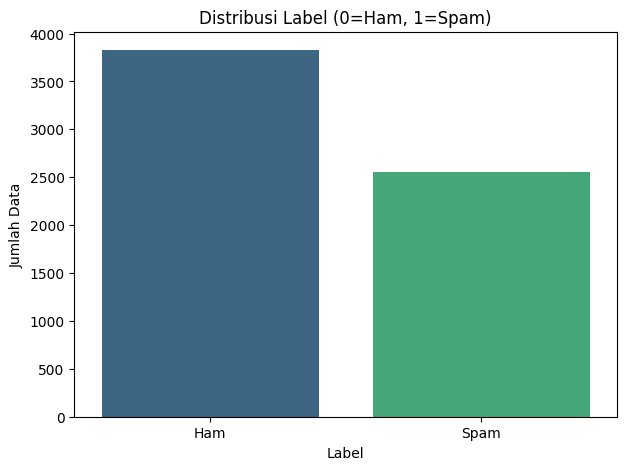

In [18]:
# Plotting the label distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='label', data=combined_df, hue='label', legend=False, palette='viridis')
plt.title('Distribusi Label (0=Ham, 1=Spam)')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [19]:
output_path = '/content/drive/MyDrive/Capstone Project_new/Dataset/combined_dataset.csv'

# Simpan ke CSV
combined_df.to_csv(output_path, index=False)

print(f"Dataset berhasil disimpan di: {output_path}")

Dataset berhasil disimpan di: /content/drive/MyDrive/Capstone Project_new/Dataset/combined_dataset.csv


## Exploratory Data Analysis (EDA)

Eksplorasi pola distribusi data, proporsi label, serta karakteristik isi pesan phishing dan non-phishing

EDA - Pertanyaan Bisnis 1: Distribusi Pesan Phishing dan Normal

In [20]:
label_counts = combined_df['label'].value_counts().sort_index()
label_pct    = combined_df['label'].value_counts(normalize=True).sort_index() * 100

distribusi_df = pd.DataFrame({
    'Kategori'  : ['Ham (Normal)', 'Spam/Phishing'],
    'Jumlah'    : [label_counts[0], label_counts[1]],
    'Persentase': [round(label_pct[0], 2), round(label_pct[1], 2)]
})

print("=== Distribusi Label Dataset ===")
display(distribusi_df)
print(f"\nTotal data: {len(combined_df)} baris")
print(f"Rasio imbalance (ham:spam) = {label_counts[0]}:{label_counts[1]} = {label_counts[0]/label_counts[1]:.2f}:1")

=== Distribusi Label Dataset ===


,Kategori,Jumlah,Persentase
0,Ham (Normal),3828,59.97
1,Spam/Phishing,2555,40.03



Total data: 6383 baris
Rasio imbalance (ham:spam) = 3828:2555 = 1.50:1


EDA - Pertanyaan Bisnis 2: Kata Dominan pada Pesan Phishing vs Normal

In [21]:
def preprocess_for_wordfreq(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Hapus URL lengkap
    text = re.sub(r'https?://\S+|www\.\S+|\S+\.(?:com|net|org|id|co\.id)\S*', ' ', text)
    # Hapus sisa fragmen domain yang lolos
    text = re.sub(r'\b(?:com|net|org|id|co|my|biz|web|info)\b', ' ', text)
    # Hapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Stopwords Bahasa Indonesia (subset umum)
STOPWORDS_ID = {
    # Stopwords umum Bahasa Indonesia
    'yang', 'dan', 'di', 'ini', 'itu', 'ke', 'dari', 'untuk', 'dengan',
    'adalah', 'atau', 'pada', 'juga', 'tidak', 'dalam', 'akan', 'ada',
    'saya', 'anda', 'kamu', 'kami', 'kita', 'dia', 'ia', 'mereka',
    'satu', 'dua', 'tiga', 'sudah', 'bisa', 'dapat', 'telah', 'lebih',
    'seperti', 'kalau', 'jika', 'maka', 'namun', 'tetapi', 'karena',
    'hingga', 'sampai', 'setelah', 'sebelum', 'serta',
    # Kata umum yang muncul di visualisasi tapi tidak informatif
    'bahwa', 'oleh', 'semua', 'hanya', 'orang', 'ingin', 'tahu',
    'hari', 'waktu', 'mungkin', 'beberapa', 'apakah', 'memiliki',
    'tentang', 'terima', 'kasih', 'sini', 'apa',
    # Kata bias dari dataset email Enron — tambahkan ini
    'perusahaan', 'bisnis', 'informasi', 'email', 'situs', 'web',
    # Stopwords Bahasa Inggris
    'the', 'a', 'an', 'is', 'in', 'on', 'at', 'to', 'of', 'and', 'or',
    'be', 'has', 'have', 'was', 'were', 'are', 'not', 'it', 'this',
    'that', 'with', 'for', 'as', 'by', 'from', 'but', 'so', 'if',
    'we', 'you', 'your', 'our', 'they', 'their', 'all', 'can', 'will',
    'just', 'about', 'only', 'also', 'more', 'here', 'there',
    # Singkatan informal
    'pls', 'msg', 'ok', 'ya', 'yg', 'ny', 'dg', 'sy', 'utk', 'jd',
    'jg', 'tp', 'lg', 'sdh', 'blm', 'bln', 'thn',
}
def get_top_words(series_text, top_n=20, stopwords=STOPWORDS_ID):
    """Hitung top N kata dari series teks."""
    all_words = []
    for text in series_text:
        processed = preprocess_for_wordfreq(text)
        words = [w for w in processed.split() if len(w) > 2 and w not in stopwords]
        all_words.extend(words)
    return Counter(all_words).most_common(top_n)

# Pisahkan berdasarkan label
ham_texts  = combined_df[combined_df['label'] == 0]['text']
spam_texts = combined_df[combined_df['label'] == 1]['text']

top_ham  = get_top_words(ham_texts,  top_n=20)
top_spam = get_top_words(spam_texts, top_n=20)

df_ham_words  = pd.DataFrame(top_ham,  columns=['Kata', 'Frekuensi'])
df_spam_words = pd.DataFrame(top_spam, columns=['Kata', 'Frekuensi'])

print("=== Top 20 Kata – Pesan Ham (Normal) ===")
display(df_ham_words)

print("\n=== Top 20 Kata – Pesan Spam/Phishing ===")
display(df_spam_words)

=== Top 20 Kata – Pesan Ham (Normal) ===


,Kata,Frekuensi
0,baru,642
1,harus,642
2,sangat,641
3,risiko,632
4,kepada,605
5,baik,603
6,penelitian,602
7,pasar,558
8,model,556
9,tahun,555



=== Top 20 Kata – Pesan Spam/Phishing ===


,Kata,Frekuensi
0,uang,760
1,gratis,695
2,baru,670
3,menjadi,652
4,banyak,621
5,klik,617
6,sekarang,616
7,secara,609
8,pesan,604
9,http,593


EDA - Pertanyaan Bisnis 3: Karakteristik Pesan Phishing dan Normal Berdasarkan Fitur Numerik

In [ ]:
# Feature Engineering - Ekstrak Fitur Numerik

# 1. Regex URL (mencari pola URL pada pesan teks)
url_pattern = (
    r'https?://[^\s]+|'
    r'www\.[^\s]+|'
    r'[a-zA-Z0-9.-]+\.(?:com|net|org|id|co\.id|my\.id|ac\.id|go\.id|info|biz)\b'
)

# 2. Helper Function (membersikah teks sederhana yang dipanggil di semua fungsi lain)
def clean_text(text):
  """Menghindari error NaN"""
  if pd.isna(text):
      return ""
  return str(text)

# 3. Ekstrak URL dari pesan (mendeteksi dan menghitung URL di dalam pesan)
def ekstrak_url(text):
    """Ambil URL pertama yang ditemukan dalam pesan"""
    text = clean_text(text)
    urls = re.findall(url_pattern, text, re.IGNORECASE)
    return urls[0] if urls else None

def ada_url(text):
    """Apakah pesan mengandung URL? 0 = tidak ada, 1 = ada"""
    text = clean_text(text)
    return int(bool(re.search(url_pattern, text, re.IGNORECASE)))

def jumlah_url(text):
    """Berapa banyak URL yang ditemukan dalam pesan?"""
    text = clean_text(text)
    return len(re.findall(url_pattern, text, re.IGNORECASE))

# 4. Fitur text pesan (menganalisis isi pesan, hanya dari kata-kata dan pola penulisan)
def panjang_pesan(text):
    return len(clean_text(text))

def jumlah_kata(text):
    return len(clean_text(text).split())

def angka_telepon(text):
    text = clean_text(text)
    pattern = r'(\+62|08)\d{8,13}'
    return int(bool(re.search(pattern, text)))

def kata_mendesak(text):
    text = clean_text(text)
    kata = (
        r'\b(segera|sekarang|expired|kadaluarsa|urgent|'
        r'darurat|deadline|hari ini|terakhir|berakhir)\b'
    )
    return int(bool(re.search(kata, text, re.IGNORECASE)))

def kata_hadiah(text):
    text = clean_text(text)
    kata = (
        r'\b(menang|pemenang|hadiah|reward|bonus|gratis|'
        r'cashback|voucher|promo|diskon|free|lucky)\b'
    )
    return int(bool(re.search(kata, text, re.IGNORECASE)))

def kata_sensitif(text):
    text = clean_text(text)
    kata = (
        r'\b(otp|pin|password|kata sandi|verifikasi|'
        r'rekening|cvv|username|login|akun|account)\b'
    )
    return int(bool(re.search(kata, text, re.IGNORECASE)))

def nama_brand(text):
    text = clean_text(text)
    brand = (
        r'\b(bca|bri|bni|mandiri|cimb|dana|ovo|gopay|'
        r'shopee|tokopedia|lazada|grab|gojek|'
        r'pln|bpjs|telkom|indosat)\b'
    )
    return int(bool(re.search(brand, text, re.IGNORECASE)))

def jumlah_tanda_seru(text):
    return clean_text(text).count('!')

def jumlah_angka(text):
    return sum(c.isdigit() for c in clean_text(text))

def jumlah_huruf_kapital(text):
    return sum(c.isupper() for c in clean_text(text))

def rasio_huruf_kapital(text):
    text = clean_text(text)
    huruf = [c for c in text if c.isalpha()]
    if len(huruf) == 0:
        return 0
    return sum(c.isupper() for c in text) / len(huruf)

def simbol(text):
    """Insight: ' Pesan menggunakan simbol berlebihan - ciri pesan tidak resmi'"""
    pola = re.compile(
        r'[\U0001F300-\U0001F9FF★✓✔☎]',
        re.UNICODE
    )
    return int(bool(pola.search(text)))

# 5. Fitur URL (menganalisis karakteristik URl yang ditemukan di dalam pesan)
def panjang_url(text):
    url = ekstrak_url(text)
    return len(url) if url else 0

def apakah_https(text):
    """Insight: Nilai 1 = ada, 0 = tidak ada"""
    url = ekstrak_url(text)
    if url:
        return int(url.startswith('https://'))
    return 0

def jumlah_titik_url(text):
    url = ekstrak_url(text)
    return url.count('.') if url else 0

def jumlah_strip_url(text):
    url = ekstrak_url(text)
    return url.count('-') if url else 0

def jumlah_subdomain(text):
    """Insight: Nilai berupa angka ditampilkan ketika nilai > 1"""
    url = ekstrak_url(text)
    if not url:
        return 0
    try:
        if not url.startswith(('http://', 'https://')):
            url = 'http://' + url
        domain = urlparse(url).netloc.lower().replace('www.', '')
        return max(0, domain.count('.') - 1)
    except:
        return 0

def apakah_url_singkat(text):
    """Insight: 'Link dibuat lebih pendek untuk menyamarkan tujuan aslinya'"""
    url = ekstrak_url(text)
    if not url:
        return 0
    layanan = ['bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly', 's.id', 'rb.gy']
    return int(any(s in url for s in layanan))

def apakah_domain_indo(text):
    url = ekstrak_url(text)
    if not url:
        return 0
    dom_indo = ['.co.id', '.my.id', '.ac.id', '.go.id', '.or.id', '.sch.id', '.web.id']
    return int(any(tld in url for tld in dom_indo))

def apakah_ip_address(text):
    url = ekstrak_url(text)
    if not url:
        return 0
    try:
        domain = url.split('//')[-1].split('/')[0].split(':')[0]
        ipaddress.ip_address(domain)
        return 1
    except:
        return 0

# 6. Mengekstrak fitur manual ke combined_df (menjalankan semua fungsi dari no.4 dan no.5 ke seluruh baris dataset)
print('Menambahkan fitur manual ke data...')

combined_df['panjang_pesan'] = combined_df['text'].apply(panjang_pesan)
combined_df['jumlah_kata'] = combined_df['text'].apply(jumlah_kata)
combined_df['ada_url'] = combined_df['text'].apply(ada_url)
combined_df['jumlah_url'] = combined_df['text'].apply(jumlah_url)
combined_df['angka_telepon'] = combined_df['text'].apply(angka_telepon)
combined_df['kata_mendesak'] = combined_df['text'].apply(kata_mendesak)
combined_df['kata_hadiah'] = combined_df['text'].apply(kata_hadiah)
combined_df['kata_sensitif'] = combined_df['text'].apply(kata_sensitif)
combined_df['nama_brand'] = combined_df['text'].apply(nama_brand)
combined_df['jumlah_tanda_seru'] = combined_df['text'].apply(jumlah_tanda_seru)
combined_df['jumlah_angka'] = combined_df['text'].apply(jumlah_angka)
combined_df['jumlah_huruf_kapital'] = combined_df['text'].apply(jumlah_huruf_kapital)
combined_df['rasio_huruf_kapital'] = combined_df['text'].apply(rasio_huruf_kapital)
combined_df['simbol'] = combined_df['text'].apply(simbol)
combined_df['panjang_url'] = combined_df['text'].apply(panjang_url)
combined_df['url_https'] = combined_df['text'].apply(apakah_https)
combined_df['jumlah_titik_url'] = combined_df['text'].apply(jumlah_titik_url)
combined_df['jumlah_strip_url'] = combined_df['text'].apply(jumlah_strip_url)
combined_df['jumlah_subdomain'] = combined_df['text'].apply(jumlah_subdomain)
combined_df['url_singkat'] = combined_df['text'].apply(apakah_url_singkat)
combined_df['domain_indo'] = combined_df['text'].apply(apakah_domain_indo)
combined_df['ip_di_url'] = combined_df['text'].apply(apakah_ip_address)

print(f"Fitur manual selesai! Total fitur: {combined_df.shape[1] - 2}")

Menambahkan fitur manual ke data...


In [ ]:
# Statistik Deskriptif Fitur Numerik per Kelas

fitur_numerik = ['panjang_pesan', 'jumlah_angka', 'rasio_huruf_kapital',
                 'jumlah_kata', 'jumlah_tanda_seru', 'jumlah_huruf_kapital']

print("=== Statistik Deskriptif – Pesan Ham (Normal) ===")
display(combined_df[combined_df['label'] == 0][fitur_numerik].describe().round(3))

print("\n=== Statistik Deskriptif – Pesan Spam/Phishing ===")
display(combined_df[combined_df['label'] == 1][fitur_numerik].describe().round(3))

In [ ]:
# Perbandingan rata-rata fitur per kelas

mean_comparison = combined_df.groupby('label')[fitur_numerik].mean().round(3)
mean_comparison.index = ['Ham (Normal)', 'Spam/Phishing']
print("=== Rata-rata Fitur Numerik per Kelas ===")
display(mean_comparison)

EDA - Pertanyaan Bisnis 4: Kemunculan Indikator Phishing pada Pesan Spam dan Normal

In [ ]:
# Mendefinisikan fitur-fitur yang dianggap sebagai indikator phishing
fitur = {
    'kata_mendesak': 'Kata Mendesak\n(urgent/segera/deadline)',
    'kata_hadiah': 'Kata Hadiah\n(gratis/menang/bonus)',
    'kata_sensitif': 'Kata Sensitif\n(OTP/PIN/password)',
    'nama_brand': 'Nama Brand\n(BCA/Shopee/GoPay)',
    'angka_telepon': 'Nomor Telepon\n(+62/08xx)',
    'ada_url': 'Mengandung URL',
    'simbol': 'Simbol/Emoji\n(★/✓/☎)'
}

# Menghitung persentase kemunculan indikator pada pesan normal dan spam
ham_pct  = combined_df[combined_df['label'] == 0][fitur.keys()].mean() * 100
spam_pct = combined_df[combined_df['label'] == 1][fitur.keys()].mean() * 100

# Membuat tabel perbandingan indikator phishing
preview_df = pd.DataFrame({
    'Fitur': fitur.values(),
    'Ham (%)': ham_pct.round(1).values,
    'Spam (%)': spam_pct.round(1).values,
    'Selisih (%)': (spam_pct - ham_pct).round(1).values
}).sort_values('Selisih (%)', ascending=False)

display(preview_df)

## Visualization & Explanatory Analysis

Visualisasi - Pertanyaan 1

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#069AF3', '#FF0000'] # Bright blue for Ham, Bright red for Spam

labels_name = ['Ham', 'Spam']
counts = [label_counts[0], label_counts[1]]

# Panel kiri: Bar chart jumlah data
bars = axes[0].bar(labels_name, counts, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Pesan per Kelas', fontsize=13, pad=10)
axes[0].set_ylabel('Jumlah Data')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].spines[['top','right']].set_visible(False)

# Panel kanan: Pie chart persentase
wedges, texts, autotexts = axes[1].pie(
    [label_pct[0], label_pct[1]],
    labels=['Ham', 'Spam'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11}  # opsional
)

# Membuat tulisan persenan menjadi bold
for autotext in autotexts:
    autotext.set_fontweight('bold'),
    autotext.set_fontsize(11)

axes[1].set_title('Persentase Label')

plt.suptitle(
   'Pertanyaan 1: Distribusi Pesan Phishing dan Normal',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

Visualisasi - Pertanyaan 2

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#069AF3', '#FF0000'] # Bright blue for Ham, Bright red for Spam

ham_words_df = pd.DataFrame(top_ham[:15], columns=['Kata', 'Frekuensi'])
spam_words_df = pd.DataFrame(top_spam[:15], columns=['Kata', 'Frekuensi'])

# Panel kiri: Kata paling sering pada pesan ham
bars_h = axes[0].barh(
    ham_words_df['Kata'][::-1],
    ham_words_df['Frekuensi'][::-1],
    color=colors[0], alpha=0.85
)
for bar in bars_h:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)
axes[0].set_title('Top 15 Kata — Ham (Pesan Normal)', fontsize=12)
axes[0].set_xlabel('Frekuensi Kemunculan')
axes[0].spines[['top','right']].set_visible(False)

# Panel kanan: Kata paling sering pada pesan spam — highlight kata kunci kritis
spam_kritis = {'otp','verifikasi','klik','hadiah','gratis','rekening','menang'}
bar_colors_s = [('#B20000' if w in spam_kritis else colors[1]) # Darker red for critical words
                for w in spam_words_df['Kata'][::-1]]
bars_s = axes[1].barh(
    spam_words_df['Kata'][::-1],
    spam_words_df['Frekuensi'][::-1],
    color=bar_colors_s, alpha=0.85
)
for bar in bars_s:
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)
axes[1].set_title('Top 15 Kata — Spam',
                  fontsize=12)
axes[1].set_xlabel('Frekuensi Kemunculan')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Pertanyaan 2: Pola Kata Dominan pada Pesan Ham dan Spam/Phishing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gunakan fungsi yang sama dengan bar chart
def build_corpus(texts):
    return " ".join(
        w
        for text in texts
        for w in preprocess_for_wordfreq(text).split()
        if len(w) > 2 and w not in STOPWORDS_ID
    )

corpus_ham  = build_corpus(ham_texts)
corpus_spam = build_corpus(spam_texts)


def red_color_func(*args, **kwargs):
    return "hsl(0, 100%, 35%)"   # merah solid untuk semua kata spam

def blue_color_func(*args, **kwargs):
    return "hsl(207, 97%, 49%)"  # biru solid untuk semua kata ham

wc_ham = WordCloud(
    width=800, height=400,
    background_color='white',
    color_func=blue_color_func,
    max_words=100,
    collocations=False,
    random_state=42
).generate(corpus_ham)

wc_spam = WordCloud(
    width=800, height=400,
    background_color='white',
    color_func=red_color_func,    # ← ganti colormap ke color_func
    max_words=100,
    collocations=False,
    random_state=42
).generate(corpus_spam)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, wc, title, color in zip(
    axes,
    [wc_ham, wc_spam],
    ['Word Cloud — Pesan Ham (Normal)',
     'Word Cloud — Pesan Spam / Phishing'],
    ['#185FA5', '#A32D2D']
):
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold',
                 pad=12, color=color)

plt.suptitle(
    'Pertanyaan 2: Pola Kata — Pesan Normal vs Phishing',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

Visualisasi - Pertanyaan 3

In [ ]:
fitur_utama = [
    ('panjang_pesan', 'Panjang Pesan'),
    ('jumlah_angka', 'Jumlah Angka'),
    ('rasio_huruf_kapital', 'Rasio Huruf Kapital')
]

ham_data = combined_df[combined_df['label'] == 0]
spam_data = combined_df[combined_df['label'] == 1]

colors = ['#069AF3', '#FF0000']
palette = {0: colors[0], 1: colors[1]}
combined_df['Kelas'] = combined_df['label'].map({0:'Ham', 1:'Spam'})

fig, axes = plt.subplots(len(fitur_utama), 3, figsize=(16, 5 * len(fitur_utama)))

for row_idx, (fitur, judul) in enumerate(fitur_utama):
    # Kolom 1: Histogram distribusi data
    ax = axes[row_idx][0]
    ax.hist(ham_data[fitur], bins=30, alpha=0.7, label='Ham', color=colors[0])
    ax.hist(spam_data[fitur], bins=30, alpha=0.7, label='Spam', color=colors[1])
    ax.set_title(f'Distribusi {judul} untuk Pesan Normal dan Phishing', fontsize=12)
    ax.set_xlabel(judul)
    ax.set_ylabel('Frekuensi')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

    # Kolom 2: Boxplot perbandingan data
    ax = axes[row_idx][1]
    sns.boxplot(
        x='Kelas', y=fitur, data=combined_df,
        hue='Kelas', palette={'Ham': colors[0], 'Spam': colors[1]},
        legend=False, ax=ax
    )
    ax.set_title(f'Boxplot {judul} berdasarkan Kelas Pesan', fontsize=12)
    ax.set_xlabel('Kelas Pesan')
    ax.set_ylabel(judul)
    ax.spines[['top','right']].set_visible(False)

    # Kolom 3: Rata-rata tiap kategori
    ax = axes[row_idx][2]
    rata_rata = [
        ham_data[fitur].mean(),
        spam_data[fitur].mean()
    ]
    bars = ax.bar(['Ham', 'Spam'], rata_rata, color=colors)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(rata_rata)*0.01),
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'Rata-rata {judul} per Kelas', fontsize=12)
    ax.set_xlabel('Kelas Pesan')
    ax.set_ylabel(f'Rata-rata {judul}')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle(
    'Pertanyaan 3: Karakteristik Fitur Numerik Pesan Normal vs. Phishing',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Visualisasi - Korelasi Fitur Numerik

In [ ]:
fitur_korelasi = [
    'panjang_pesan',
    'jumlah_kata',
    'jumlah_angka',
    'jumlah_huruf_kapital',
    'rasio_huruf_kapital',
    'jumlah_tanda_seru',
    'kata_mendesak',
    'kata_hadiah',
    'kata_sensitif',
    'ada_url',
    'label'
]

corr_matrix = combined_df[fitur_korelasi].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi Fitur Numerik dengan Label',
          fontsize=14
)
plt.show()

Visualisasi - Pertanyaan 4

In [ ]:
fitur = {
    'kata_mendesak': 'Kata Mendesak\n(urgent/segera/deadline)',
    'kata_hadiah': 'Kata Hadiah\n(gratis/menang/bonus)',
    'kata_sensitif': 'Kata Sensitif\n(OTP/PIN/password)',
    'nama_brand': 'Nama Brand\n(BCA/Shopee/GoPay)',
    'angka_telepon': 'Nomor Telepon\n(+62/08xx)',
    'ada_url': 'Mengandung URL',
    'simbol': 'Simbol/Emoji\n(★/✓/☎)'
}
x = np.arange(len(fitur))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

# Standardized colors for Ham and Spam
colors_ham = '#069AF3'  # Bright blue
colors_spam = '#FF0000' # Bright red

# Bar chart pesan normal
bars_h = ax.bar(
    x - width/2, ham_pct, width,
    label='Ham (Normal)', color=colors_ham
)

# Bar chart pesan spam/phishing
bars_s = ax.bar(
    x + width/2, spam_pct, width,
    label='Spam/Phishing', color=colors_spam
)

# Menampilkan persentase di atas setiap bar
for bars, color_text in [(bars_h, colors_ham), (bars_s, colors_spam)]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{bar.get_height():.0f}%',
            ha='center',
            va='bottom',
            fontsize=9,
            color=color_text # Changed text color to match bar color
        )

# Pengaturan tampilan grafik
ax.set(
    xticks=x,
    xticklabels=list(fitur.values()),
    ylabel='Persentase Pesan (%)',
    ylim=(0, max(spam_pct) * 1.2)
)

ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    'Pertanyaan 4: Persentase Kemunculan Indikator Phishing pada Pesan Spam dan Normal',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Features Engineering

In [ ]:
# Preprocessing untuk TF-IDF (membersihkan teks sebelum dimasukan ke TF-IDF)
def preprocess_text(text):
    text = clean_text(text).lower()
    text = re.sub(url_pattern, ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# TF-IDF (mengubah pesan teks ke bentuk angka sesuai tingkat kepentingan kata)
print("Membuat TF-IDF...")

teks_bersih = combined_df['text'].apply(preprocess_text)

tfidf = TfidfVectorizer(
    max_features=1000, #membatasi jumlah fitur/kata maksimal sebanyak 1000
    ngram_range=(1, 2), #menggunakan unigram dan bigram (1 kata dan 2 kata)
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(teks_bersih) #mengubah teks menjadi matriks TF-IDF

print(f"TF-IDF selesai! Shape: {X_tfidf.shape}")

In [ ]:
# Menggabungkan TF-IDF + Fitur Manual

fitur_manual_cols = [
    'panjang_pesan', 'jumlah_kata', 'ada_url', 'jumlah_url',
    'angka_telepon', 'kata_mendesak', 'kata_hadiah', 'kata_sensitif',
    'nama_brand', 'jumlah_tanda_seru', 'jumlah_angka',
    'jumlah_huruf_kapital', 'rasio_huruf_kapital', 'simbol',
    'panjang_url', 'url_https', 'jumlah_titik_url',
    'jumlah_strip_url', 'jumlah_subdomain', 'url_singkat',
    'domain_indo', 'ip_di_url'
]

X_manual = sp.csr_matrix(combined_df[fitur_manual_cols].values)
X_all    = sp.hstack([X_tfidf, X_manual])
y        = combined_df['label'].values

print(f"Shape fitur gabungan (TF-IDF + Manual): {X_all.shape}")
print(f"Total fitur: {X_all.shape[1]} ({X_tfidf.shape[1]} TF-IDF + {len(fitur_manual_cols)} manual)")


# Simpan hasil
output_feat_path = folder_dataset + 'combined_dataset_features.csv'
combined_df.to_csv(output_path, index=False)
print(f"Dataset fitur berhasil disimpan: {output_feat_path}")
print(f"Total kolom: {combined_df.shape[1]}")
display(combined_df.head())

### Penjelasan Kolom Fitur Ekstrak URL:
*   **`ada_url`**: Penanda ada atau tidaknya URL dalam pesan (1 = ada, 0 = tidak ada).
*   **`jumlah_url`**: Menghitung berapa URL yang ada dalam satu pesan. Semakin banyak URL dalam satu pesan, semakin besar kemungkinan pesan tersebut adalah phishing atau spam.


### Penjelasan Kolom Fitur Pesan Teks:
*   **`panjang_pesan`**: Jumlah karakter dalam pesan. Pesan phishing biasanya sangat panjang karena berisi promosi atau instruksi tertentu, atau justru sangat pendek karena hanya memuat tautan.
*   **`jumlah_kata`**: Jumlah kata dalam pesan. Fitur ini melengkapi `panjang_pesan` untuk melihat seberapa padat isi pesan.
*   **`angka_telepon`**: Penanda ada atau tidaknya nomor telepon format Indonesia (+62 atau 08) dalam pesan (1 = ada, 0 = tidak ada).
*   **`kata_mendesak`**: Penanda ada atau tidaknya kata-kata yang terkesan mendesak seperti *segera*, *urgent*, *deadline*, atau *berakhir* (1 = ada, 0 = tidak ada).
*   **`kata_hadiah`**: Penanda ada atau tidaknya kata-kata iming-iming seperti *menang*, *hadiah*, *gratis*, *cashback*, atau *promo* (1 = ada, 0 = tidak ada).
*   **`kata_sensitif`**: Penanda ada atau tidaknya kata-kata sensitif seperti *OTP*, *PIN*, *password*, *rekening*, atau *verifikasi* (1 = ada, 0 = tidak ada).
*   **`nama_brand`**: Penanda ada atau tidaknya nama merek atau lembaga terkenal seperti BCA, Shopee, GoPay, atau PLN dalam pesan (1 = ada, 0 = tidak ada).
*   **`jumlah_tanda_seru`**: Jumlah tanda seru (`!`) dalam pesan. Tanda seru yang terlalu banyak biasanya menandakan pesan yang tidak resmi.
*   **`jumlah_angka`**: Jumlah digit angka (0 – 9) dalam pesan. Pesan spam sering memuat banyak angka seperti nominal uang, kode promo, atau nomor rekening.
*   **`jumlah_huruf_kapital`**: Jumlah huruf kapital dalam pesan. Penggunaan huruf kapital berlebihan sering digunakan untuk menarik perhatian penerima pesan.
*   **`rasio_huruf_kapital`**: Perbandingan jumlah huruf kapital dengan seluruh huruf dalam pesan (0.0 – 1.0). Nilai yang tinggi menandakan gaya penulisan yang sering ditemukan pada pesan spam.
*   **`simbol`**: Penanda ada atau tidaknya simbol atau emoji berlebihan seperti ★, ✓, ☎, atau sejenisnya (1 = ada, 0 = tidak ada). Simbol berlebihan adalah ciri pesan tidak resmi.

## **Conclusion & Recommendation**

### Kesimpulan

* **Pertanyaan 1 — Distribusi Pesan Phishing dan Normal:**
 Dataset memiliki jumlah pesan Ham (normal) yang sedikit lebih banyak dibandingkan pesan Spam/Phishing dengan rasio sekitar 1.5:1. Perbedaan tersebut menunjukkan adanya ketidakseimbangan data, tetapi masih dalam kategori ringan sehingga distribusi kedua kelas masih cukup baik untuk proses pelatihan model. Meski begitu, evaluasi performa model tetap perlu diperhatikan agar kemampuan deteksi phishing tidak menurun dan model tidak terlalu condong ke kelas Ham.

* **Pertanyaan 2 — Kata Dominan pada Pesan Phishing:**
  Pesan phishing lebih banyak mengandung kata yang bersifat ajakan, promosi, dan urgensi seperti **“uang”**, **“gratis”**, **“klik”**, **“sekarang”**, dan **“http”**. Kata-kata tersebut sering digunakan untuk menarik perhatian pengguna dan mengarahkan korban ke tautan tertentu. Sementara itu, pesan normal lebih banyak menggunakan kata umum yang bersifat netral dan digunakan dalam percakapan sehari-hari.

* **Pertanyaan 3 — Karakteristik Pesan Berdasarkan Fitur Numerik:**
  Pesan phishing memiliki **jumlah angka lebih banyak**, **rasio huruf kapital lebih tinggi**, dan **panjang pesan yang lebih bervariasi** dibandingkan pesan normal. Banyaknya angka ini berkaitan dengan nominal uang, nomor rekening, atau kode OTP. Selain itu, penggunaan huruf kapital pada pesan phishing sering digunakan untuk memberi kesan mendesak dan menarik perhatian pengguna.

* **Pertanyaan 4 — Kemunculan Indikator Phishing:**
  Beberapa indikator phishing muncul lebih dominan pada pesan spam dibandingkan pesan normal, seperti **kata sensitif** (*OTP, PIN, password, rekening*), **kata mendesak** (*segera, urgent, berakhir*), **URL/http**, **nomor telepon**, serta **nama brand** tertentu. Kemunculan indikator tersebut menunjukkan pola yang cukup kuat dalam pesan phishing sehingga dapat dimanfaatkan sebagai fitur tambahan dalam proses klasifikasi.

---

### Rekomendasi Action Item

**1. Penggabungan Fitur Teks dan Fitur Manual (dari Q2 & Q3)**
Gunakan kombinasi fitur TF-IDF dengan fitur manual seperti panjang pesan, jumlah angka, rasio huruf kapital, URL, nomor telepon, dan kata sensitif agar model memiliki informasi yang lebih lengkap dalam membedakan pesan phishing dan pesan normal.

**2. Evaluasi Distribusi Data dan Performa Model (dari Q1)**
Karena perbedaan jumlah data antara kelas Ham dan Spam masih tergolong ringan, model tetap dapat dilatih tanpa penanganan imbalance khusus. Namun, evaluasi performa seperti precision, recall, dan F1-score tetap perlu dilakukan untuk memastikan model mampu mendeteksi pesan phishing dengan baik.

**3. Prioritas pada Indikator Phishing Penting (dari Q4)**
Berikan perhatian lebih pada fitur yang sering muncul pada pesan phishing, terutama pada kata sensitif, kata mendesak, URL/http, dan nomor telepon karena indikator tersebut memiliki hubungan yang cukup kuat dengan aktivitas phishing.
